In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "eia_tx_energy_time_series_features.csv"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["period"],
)

df = (
    df.sort_values("period")
    .reset_index(drop=True)
)

df.head()

,period,commercial_customers,commercial_price,commercial_revenue,commercial_sales,industrial_customers,industrial_price,industrial_revenue,industrial_sales,residential_customers,...,residential_price_stl_residual,residential_sales_per_customer_kwh_stl_trend,residential_sales_per_customer_kwh_stl_seasonal,residential_sales_per_customer_kwh_stl_residual,renewable_share_stl_trend,renewable_share_stl_seasonal,renewable_share_stl_residual,natural_gas_share_stl_trend,natural_gas_share_stl_seasonal,natural_gas_share_stl_residual
0,2015-01-01,1424841.0,8.40,910.06698,10834.88707,97914.0,5.93,502.67896,8481.28780,10236358.0,...,-0.038004,1175.350639,79.093871,39.361364,0.099609,-0.008030,-0.004863,0.516346,-0.007951,-0.002218
1,2015-02-01,1414177.0,8.50,842.24433,9903.83625,101493.0,5.84,471.33029,8076.96359,10222635.0,...,-0.011462,1171.199189,-111.972343,15.325182,0.102617,0.019648,-0.018795,0.516957,-0.008235,0.001376
2,2015-03-01,1421352.0,8.49,895.83199,10548.75206,102666.0,5.79,502.20327,8667.54624,10292791.0,...,-0.161233,1167.241417,-338.828984,252.199674,0.105556,0.060981,-0.083098,0.517526,0.056354,-0.002901
3,2015-04-01,1417183.0,7.98,840.64570,10540.04355,104227.0,5.54,491.40865,8870.68519,10302930.0,...,0.094533,1163.462682,-331.843520,-3.866196,0.108435,0.025220,0.003492,0.518045,0.027271,-0.002158
4,2015-05-01,1411987.0,8.21,868.98021,10588.54603,105413.0,5.56,507.11835,9122.37774,10288519.0,...,0.098451,1159.844311,-226.353425,-7.857418,0.111264,0.015401,0.003087,0.518508,-0.005662,-0.009728


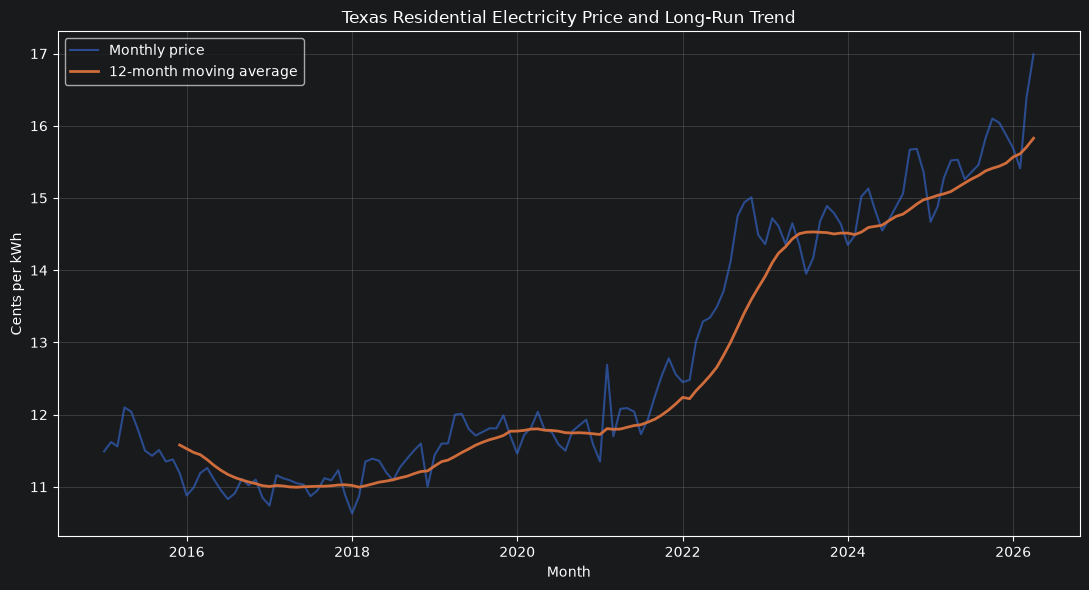

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["residential_price"],
    label="Monthly price",
    alpha=0.6,
)

ax.plot(
    df["period"],
    df["residential_price_ma12"],
    label="12-month moving average",
    linewidth=2,
)

ax.set_title(
    "Texas Residential Electricity Price and Long-Run Trend"
)
ax.set_xlabel("Month")
ax.set_ylabel("Cents per kWh")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_residential_price_ma12.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

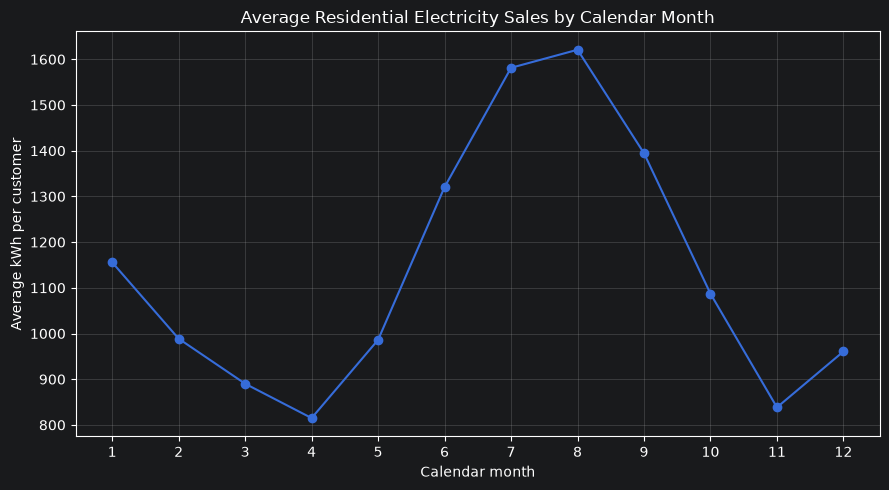

In [4]:
monthly_profile = (
    df.groupby(
        "month",
        as_index=False,
    )[
        "residential_sales_per_customer_kwh"
    ]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_profile["month"],
    monthly_profile[
        "residential_sales_per_customer_kwh"
    ],
    marker="o",
)

ax.set_title(
    "Average Residential Electricity Sales by Calendar Month"
)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Average kWh per customer")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_residential_monthly_seasonal_profile.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

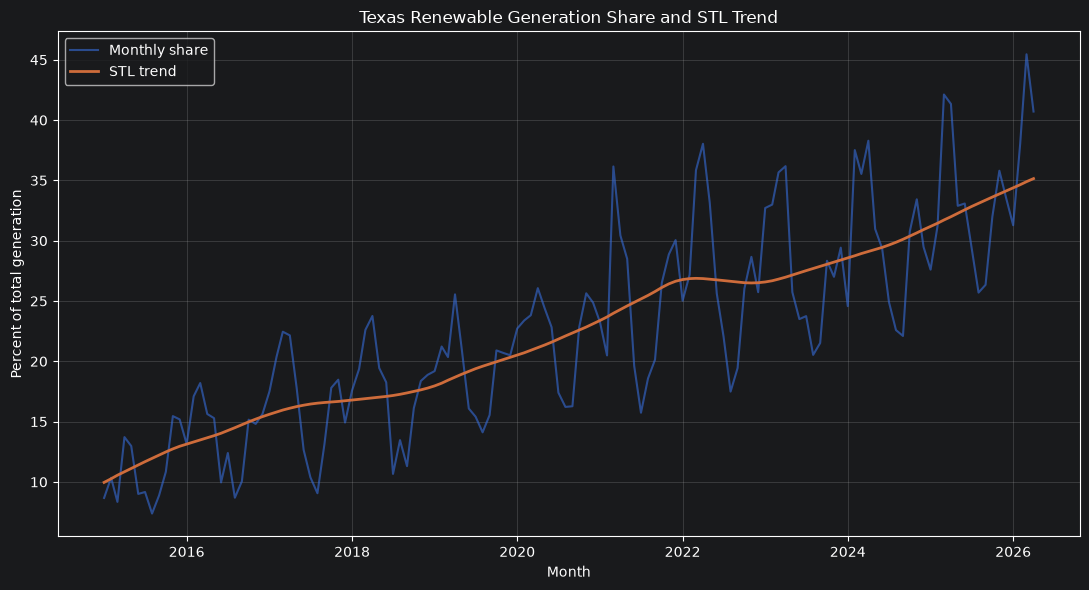

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["renewable_share"] * 100,
    label="Monthly share",
    alpha=0.6,
)

ax.plot(
    df["period"],
    df[
        "renewable_share_stl_trend"
    ] * 100,
    label="STL trend",
    linewidth=2,
)

ax.set_title(
    "Texas Renewable Generation Share and STL Trend"
)
ax.set_xlabel("Month")
ax.set_ylabel("Percent of total generation")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_renewable_share_stl_trend.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

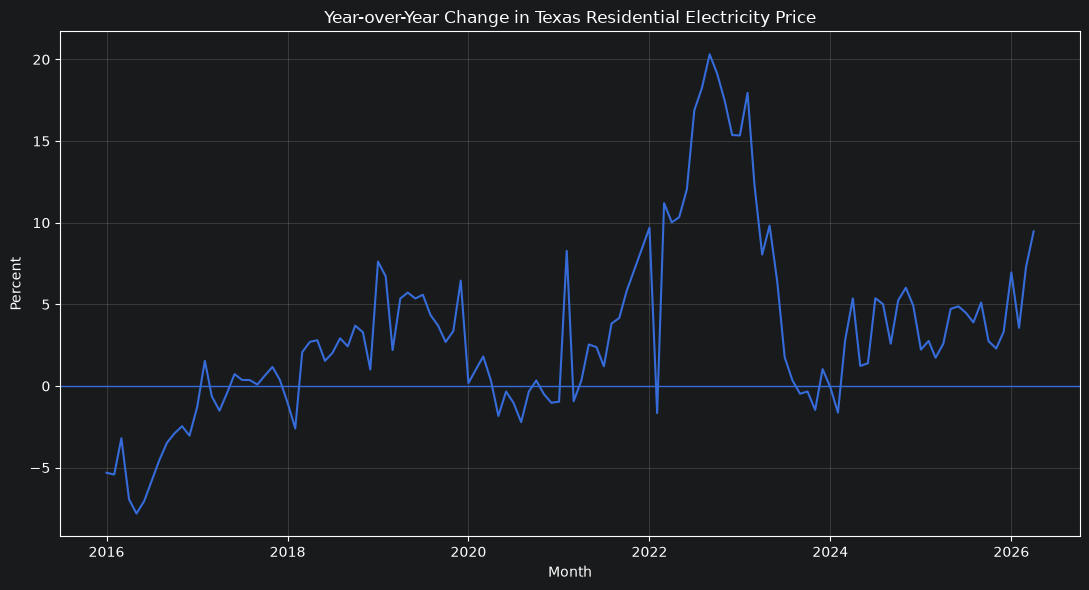

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["residential_price_yoy_pct"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Year-over-Year Change in Texas Residential Electricity Price"
)
ax.set_xlabel("Month")
ax.set_ylabel("Percent")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_residential_price_yoy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()